# Anomaly Detection
Identifying months with unusual hydroclimatic conditions using Isolation Forest. Unlike the drought indices in the 3rd notebook which focus on precipitation alone, this approach detects anomalies in a combination of all climate variables simultaneously.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
bcolor="darkslategrey"

df = pd.read_csv("../data/processed/mendoza_basin_with_indices.csv", parse_dates=["time"], index_col="time")

print(f"Loaded {len(df)} months")
print(f"NaN counts:\n{df.isnull().sum()}")

Loaded 540 months
NaN counts:
precip_mm               0
temp_c                  0
pev_mm                  0
runoff_mm               0
soil_moisture_0_7cm     0
spi3                    2
spi6                    5
spi12                  11
spei3                   2
spei6                   5
dtype: int64


## Unsupervised Isolation Forest

Fitting an unsupervised anomaly detection model on the five core climate variables. The model identifies months where the multivariate combination of conditions is statistically unusual, not just extreme in one variable, but unusual in how the variables relate to each other.

In [6]:
features = ["precip_mm", "temp_c", "pev_mm", "runoff_mm", "soil_moisture_0_7cm"]

df_features = df[features].dropna()
print(f"Months available: {len(df_features)}")

scaler = StandardScaler()
x_scaled = scaler.fit_transform(df_features)

iso_forest = IsolationForest(
    contamination=0.05,
    n_estimators=200,
    random_state=42,
)
predictions = iso_forest.fit_predict(x_scaled)
scores = iso_forest.decision_function(x_scaled)

df_features = df_features.copy()
df_features["anomaly"] = predictions
df_features["anomaly_score"] = scores

n_anomalies = (predictions == -1).sum()
print(f"Anomalies: {n_anomalies} out of {len(df_features)} months ({n_anomalies/len(df_features)*100:.1f}%)") 

Months available: 540
Anomalies: 27 out of 540 months (5.0%)


## Anomaly Timeline
Anomalous months plotted against precipitation and soil moisture time series, red markers indicate months flagged by the Isolation Forest as anomalous.

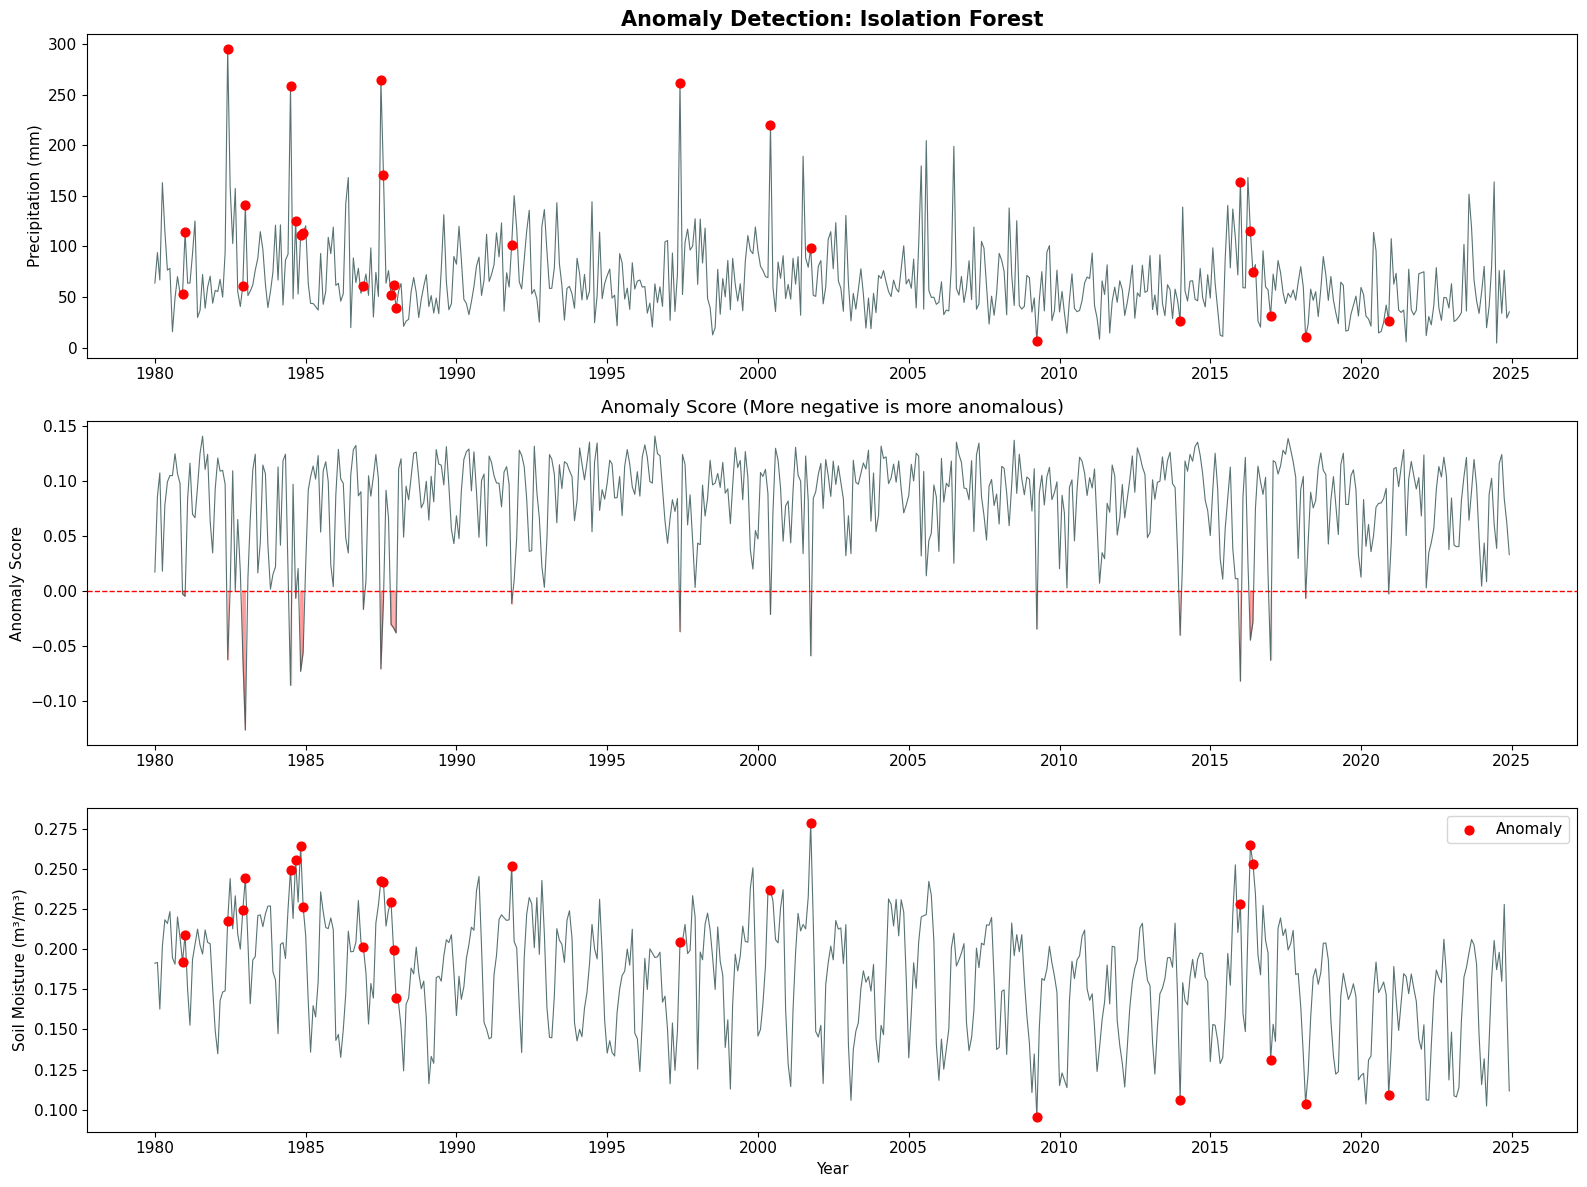

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

anom_mask = df_features["anomaly"] == -1

# Precipitation with anomalies
ax = axes[0]
ax.plot(
    df_features.index,
    df_features["precip_mm"],
    color=bcolor,
    linewidth=0.8,
    alpha=0.8,
)
ax.scatter(
    df_features.index[anom_mask],
    df_features.loc[anom_mask, "precip_mm"],
    color="red",
    s=40,
    zorder=5,
    label=f"Anomaly ({n_anomalies} months)"
)
ax.set_ylabel("Precipitation (mm)")
ax.set_title("Anomaly Detection: Isolation Forest", fontsize=15, fontweight="bold")

# Anomaly Score over time
ax = axes[1]
ax.plot(
    df_features.index,
    df_features["anomaly_score"],
    color=bcolor,
    linewidth=0.8,
    alpha=0.8,
)
ax.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=1,
)
ax.fill_between(
    df_features.index,
    df_features["anomaly_score"],
    0,
    where=df_features["anomaly_score"] < 0,
    color="red",
    alpha=0.3,
)
ax.set_ylabel("Anomaly Score")
ax.set_title("Anomaly Score (More negative is more anomalous)")

# SOil moisture with anomalies
ax = axes[2]
ax.plot(
    df_features.index, 
    df_features["soil_moisture_0_7cm"], 
    color=bcolor,
    linewidth=0.8, 
    alpha=0.8,
)
ax.scatter(
    df_features.index[anom_mask], 
    df_features.loc[anom_mask, "soil_moisture_0_7cm"],
    color="red", 
    s=40, 
    zorder=5, 
    label="Anomaly"
)
ax.set_ylabel("Soil Moisture (m³/m³)")
ax.set_xlabel("Year")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/anomaly_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

## What makes a month anomalous?

I compare the average conditions during anomalous months vs normal months. This reveals whether anomalies are driven by a single extreme variable or a combination.

What makes a month anomalous?
                     Normal mean  Anomalous mean  Difference  Diff %
precip_mm              64.718658      113.127324   48.408666    74.8
temp_c                  7.907444        9.140063    1.232620    15.6
pev_mm                103.214503      117.170385   13.955882    13.5
runoff_mm              23.754751       70.515807   46.761055   196.8
soil_moisture_0_7cm     0.180666        0.208569    0.027903    15.4


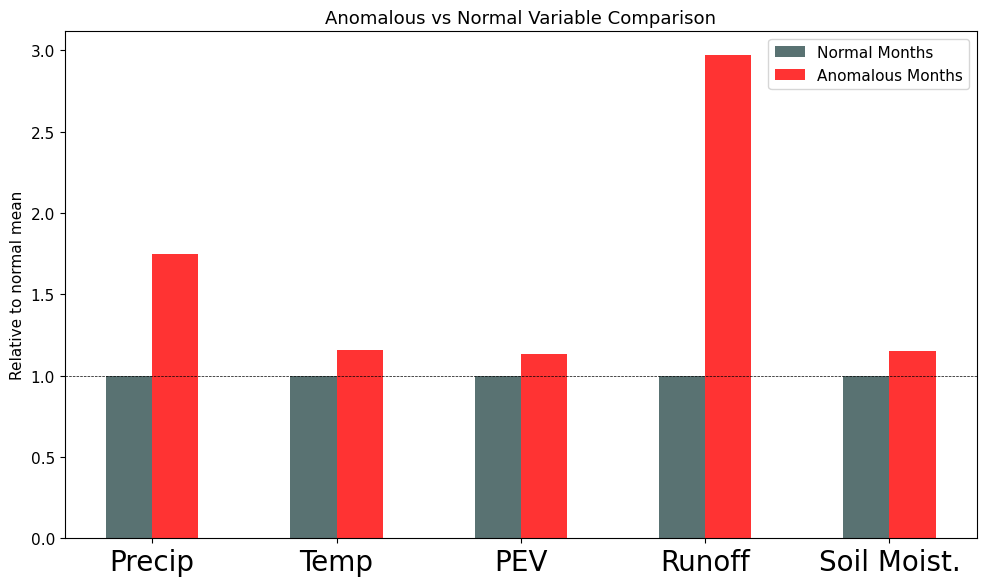

In [16]:
normal = df_features[df_features["anomaly"] == 1][features]
anomalous = df_features[df_features["anomaly"] == -1][features]

comparison = pd.DataFrame({
    "Normal mean": normal.mean(),
    "Anomalous mean": anomalous.mean(),
    "Difference": anomalous.mean() - normal.mean(),
    "Diff %": ((anomalous.mean() - normal.mean()) / normal.mean() * 100).round(1),
})

print("What makes a month anomalous?")
print(comparison.to_string())

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(features))
width = 0.25

normal_scaled = normal.mean() / normal.mean()
anomalous_scaled = anomalous.mean() / normal.mean()

ax.bar(
    x - width/2, 
    normal_scaled,
    width,
    label="Normal Months",
    color=bcolor,
    alpha=0.8,
)
ax.bar(
    x + width/2, 
    anomalous_scaled,
    width,
    label="Anomalous Months",
    color="red",
    alpha=0.8,
)
ax.axhline(
    y=1.0,
    color="black",
    linestyle="--",
    linewidth=0.5,
)
ax.set_ylabel("Relative to normal mean")
ax.set_title("Anomalous vs Normal Variable Comparison")
ax.set_xticks(x)
ax.set_xticklabels(["Precip", "Temp", "PEV", "Runoff", "Soil Moist."], fontsize=20)
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/anomaly_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Cross Reference with Drought Index

Do the multivariate anomalies align with the drought events identified by SPI6 in the 3rd notebook? If anomalous months tend to coincide with low SPI6 values, this validates both ideas.

SPI6 during anomalous vs normal months
    Normal months mean SPI6:    -0.048
    Anomalous months mean SPI6: +0.895
    Anomalous months in drought (SPI-6 < -1.0): 4/27 (15%)


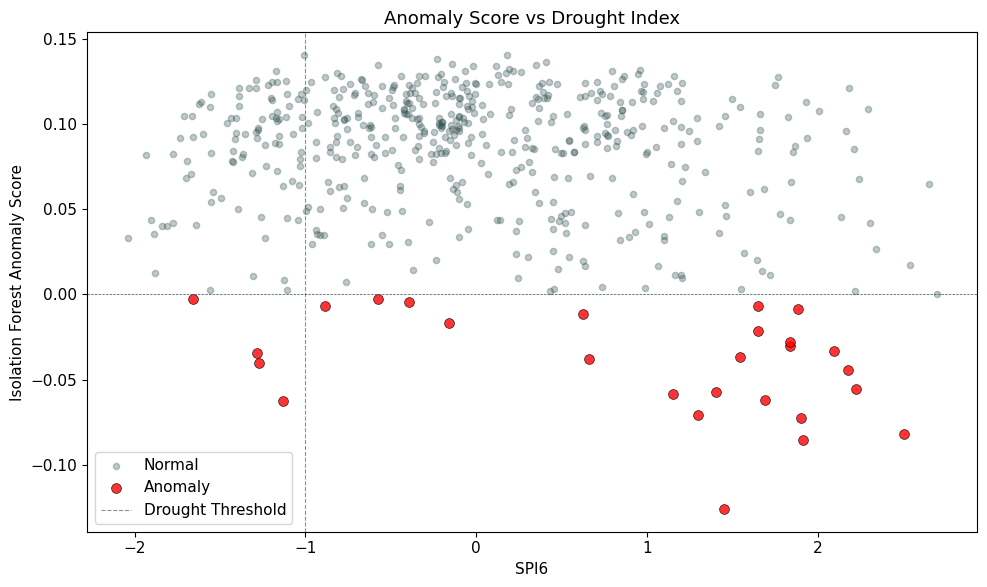

In [24]:
df_combined = df_features[["anomaly", "anomaly_score"]].join(df[["spi6", "spi3"]], how="inner")
df_combined = df_combined.dropna()

normal_spi = df_combined[df_combined["anomaly"] == 1]["spi6"]
anomalous_spi = df_combined[df_combined["anomaly"] == -1]["spi6"]

print("SPI6 during anomalous vs normal months")
print(f"    Normal months mean SPI6:    {normal_spi.mean():+.3f}")
print(f"    Anomalous months mean SPI6: {anomalous_spi.mean():+.3f}")

anom_drought = (df_combined[df_combined["anomaly"] == -1]["spi6"] < -1.0).sum()
anom_total = (df_combined["anomaly"] == -1).sum()
print(f"    Anomalous months in drought (SPI-6 < -1.0): {anom_drought}/{anom_total} ({anom_drought/anom_total*100:.0f}%)")

fig, ax = plt.subplots(figsize=(10, 6))

normal_mask = df_combined["anomaly"] == 1
anom_mask = df_combined["anomaly"] == -1

ax.scatter(
    df_combined.loc[normal_mask, "spi6"],
    df_combined.loc[normal_mask, "anomaly_score"],
    alpha=0.3,
    s=20,
    color=bcolor,
    label="Normal",
)
ax.scatter(
    df_combined.loc[anom_mask, "spi6"],
    df_combined.loc[anom_mask, "anomaly_score"],
    alpha=0.8,
    s=50,
    color="red",
    edgecolors="black",
    linewidth=0.5,
    label="Anomaly",
)
ax.axhline(
    y=0,
    color=bcolor,
    linestyle="--",
    linewidth=0.5,
)
ax.axvline(
    x=-1.0,
    color=bcolor,
    linestyle="--",
    linewidth=0.8,
    alpha=0.6,
    label="Drought Threshold",
)
ax.set_xlabel("SPI6")
ax.set_ylabel("Isolation Forest Anomaly Score")
ax.set_title("Anomaly Score vs Drought Index")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/anomaly_vs_spi.png", dpi=150, bbox_inches="tight")
plt.show()

## All Anomalous Months

In [30]:
anomalous_months = df_features[df_features["anomaly"] == -1].copy()
anomalous_months = anomalous_months.join(df[["spi6"]], how="left")
anomalous_months = anomalous_months.sort_values("anomaly_score")

print(f"All {len(anomalous_months)} anomalous months:\n")
print(f"{'Date':>10s}  {'Precip':>8s}  {'Temp':>6s}  {'PEV':>8s}  {'Runoff':>8s}  {'Soil':>6s}  {'SPI6':>6s}  {'Score':>8s}")
for idx, row in anomalous_months.iterrows():
    print(
        f"{str(idx.date()):>10s}  "
        f"{row['precip_mm']:8.2f}  "
        f"{row['temp_c']:6.2f}  "
        f"{row['pev_mm']:8.2f}  "
        f"{row['runoff_mm']:8.2f}  "
        f"{row['soil_moisture_0_7cm']:6.2f}"
        f"{row['spi6']:6.2f}"
        f"{row['anomaly_score']:8.3f}"
)

All 27 anomalous months:

      Date    Precip    Temp       PEV    Runoff    Soil    SPI6     Score
1983-01-01    140.57   14.33    144.83    163.42    0.24  1.45  -0.126
1984-07-01    258.15   -0.60     20.64     23.30    0.25  1.91  -0.086
2016-01-01    163.67   15.28    158.82    120.03    0.23  2.51  -0.082
1984-11-01    111.52    9.35    113.73     90.78    0.26  1.90  -0.073
1987-07-01    263.89   -0.10     27.09     30.85    0.24  1.30  -0.071
2017-01-01     31.22   18.33    220.28     57.23    0.13 -1.13  -0.063
1982-06-01    294.95    0.14     21.90     19.76    0.22  1.69  -0.062
2001-10-01     98.24    8.20     90.12     67.35    0.28  1.15  -0.059
1982-12-01     60.75   14.03    162.78    170.02    0.22  1.40  -0.057
1984-12-01    113.71   11.76    150.27    131.87    0.23  2.22  -0.056
2016-05-01    114.89    2.44     26.02     38.28    0.26  2.18  -0.044
2014-01-01     26.36   17.75    229.05     16.42    0.11 -1.27  -0.040
1988-01-01     39.17   14.74    194.29    114.0